In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

european_tickers = ['ENEL.MI', 'ISP.MI', 'ENI.MI', 'AIR.PA', 'MC.PA', 'OR.PA','SAP.DE', 'SIE.DE', 'ALV.DE', 'IBE.MC', 'SAN.MC', 'ASML.AS']

# 1. Using ticker().history() to concatenate
series_list = []

for ticker in european_tickers:
    try:
        # Downloading last 5 years of data
        data = yf.Ticker(ticker).history(period="5y")
        # If data exists, take the 'Close' column and rename it with the ticker
        if not data.empty and 'Close' in data.columns:
            clean_series = data['Close'].rename(ticker)
            series_list.append(clean_series)
    except Exception:
        print(f"Skipped {ticker} due to API connection issues.")

# Using pd.concat to merge all columns automatically and align dates
prices = pd.concat(series_list, axis=1)
prices = prices.fillna(method='ffill').dropna()

# 2. Loading ESG data from local CSV file
esg = pd.read_csv('european_esg_scores.csv', index_col=0)

# 3. Log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# 4. Creating Green and Brown lists
esg_sorted = esg.sort_values(by='ESG_Risk_Score')
half_size = len(esg_sorted) // 2
green_tickers = esg_sorted.index[:half_size].tolist()
brown_tickers = esg_sorted.index[half_size:].tolist()

# Filtering to ensure we only use tickers successfully downloaded
valid_green = [t for t in green_tickers if t in log_returns.columns]
valid_brown = [t for t in brown_tickers if t in log_returns.columns]

# 5. Portfolio returns calculation
port_green_returns = log_returns[valid_green].mean(axis=1)
port_brown_returns = log_returns[valid_brown].mean(axis=1)

In [3]:
import yfinance as yf
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Using the official index instead of the ETF. If STOXX fails, fallback to VGK (Vanguard Europe ETF)
try:
    bench_data = yf.Ticker('^STOXX').history(period="5y")
    if bench_data.empty:
        bench_data = yf.Ticker('VGK').history(period="5y")
except:
    bench_data = yf.Ticker('VGK').history(period="5y")

benchmark = bench_data['Close']
bench_returns = np.log(benchmark / benchmark.shift(1)).dropna()

# 2. Converting indices to plain string format ('YYYY-MM-DD')
port_green_returns.index = pd.to_datetime(port_green_returns.index).strftime('%Y-%m-%d')
port_brown_returns.index = pd.to_datetime(port_brown_returns.index).strftime('%Y-%m-%d')
bench_returns.index = pd.to_datetime(bench_returns.index).strftime('%Y-%m-%d')

# 3. Merging datasets (join='inner' keeps only common trading days)
data_capm = pd.concat([port_green_returns, port_brown_returns, bench_returns], axis=1, join='inner')
data_capm.columns = ['Green', 'Brown', 'Market']

print(f"Aligned trading days: {len(data_capm)} observations")

# 4. Data validation and CAPM estimation
if len(data_capm) < 100:
    print("ERROR: Insufficient data. API limitations may have affected data retrieval.")
else:
    def calculate_capm(portfolio_returns, market_returns):
        # Adding constant term (Alpha)
        X = sm.add_constant(market_returns)
        Y = portfolio_returns
        
        # OLS Regression
        model = sm.OLS(Y, X).fit()
        
        # Extracting parameters
        alpha_annualized = model.params.iloc[0] * 252
        beta = model.params.iloc[1]
        r_squared = model.rsquared
        
        return alpha_annualized, beta, r_squared

    # 5. Model estimation and output
    alpha_g, beta_g, r2_g = calculate_capm(data_capm['Green'], data_capm['Market'])
    alpha_b, beta_b, r2_b = calculate_capm(data_capm['Brown'], data_capm['Market'])

    print("\n--- RISULTATI CAPM ---")
    print(f"GREEN PORTFOLIO -> Annualized Alpha: {alpha_g:.4f} | Beta: {beta_g:.4f} | R-squared: {r2_g:.4f}")
    print(f"BROWN PORTFOLIO -> Annualized Alpha: {alpha_b:.4f} | Beta: {beta_b:.4f} | R-squared: {r2_b:.4f}")

Aligned trading days: 998 observations

--- RISULTATI CAPM ---
GREEN PORTFOLIO -> Annualized Alpha: 0.1669 | Beta: -0.1505 | R-squared: 0.0095
BROWN PORTFOLIO -> Annualized Alpha: 0.1269 | Beta: -0.1275 | R-squared: 0.0109


In [5]:
import pandas as pd

# Creating a tabular summary of CAPM results
capm_summary = pd.DataFrame({
    'Metric': ['Annualized Alpha', 'Beta', 'R-squared'],
    'Green Portfolio': [alpha_g, beta_g, r2_g],
    'Brown Portfolio': [alpha_b, beta_b, r2_b]
}).set_index('Metric')

# Exporting results to CSV file
capm_summary.to_csv('capm_results.csv')

print("Results successfully exported to 'capm_results.csv'.")
display(capm_summary.round(4))

Results successfully exported to 'capm_results.csv'.


,Green Portfolio,Brown Portfolio
Metric,,
Annualized Alpha,0.1669,0.1269
Beta,-0.1505,-0.1275
R-squared,0.0095,0.0109


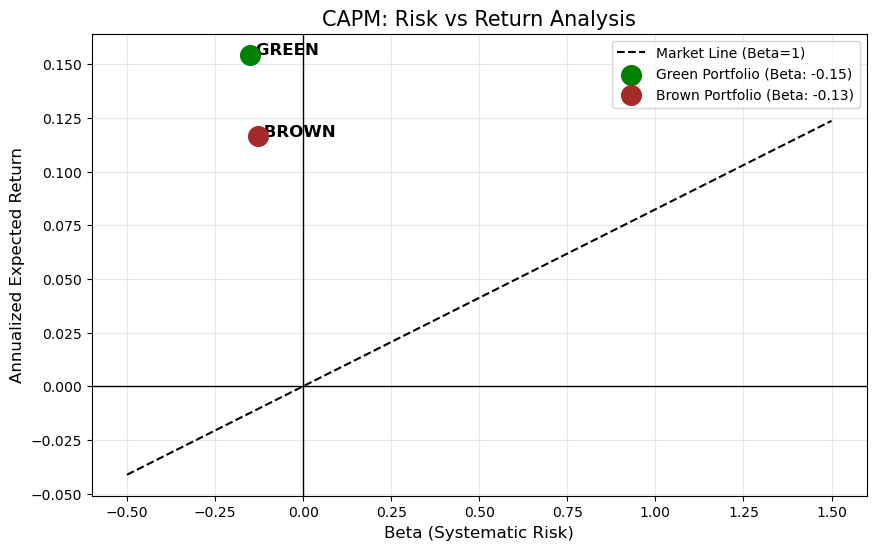

In [7]:
import matplotlib.pyplot as plt

# Creating the Security Market Line (SML) plot
plt.figure(figsize=(10, 6))

# Computing points for the market line (Beta=1, Alpha=0)
market_range = np.linspace(-0.5, 1.5, 100)
plt.plot(market_range, market_range * data_capm['Market'].mean() * 252, 
         color='black', linestyle='--', label='Market Line (Beta=1)')

# Plot portfolio positions
plt.scatter(beta_g, alpha_g + (beta_g * data_capm['Market'].mean() * 252), 
            color='green', s=200, label=f'Green Portfolio (Beta: {beta_g:.2f})', zorder=5)
plt.scatter(beta_b, alpha_b + (beta_b * data_capm['Market'].mean() * 252), 
            color='brown', s=200, label=f'Brown Portfolio (Beta: {beta_b:.2f})', zorder=5)

# Adding labels near the points
plt.annotate(' GREEN', (beta_g, alpha_g + (beta_g * data_capm['Market'].mean() * 252)), fontsize=12, fontweight='bold')
plt.annotate(' BROWN', (beta_b, alpha_b + (beta_b * data_capm['Market'].mean() * 252)), fontsize=12, fontweight='bold')

plt.title('CAPM: Risk vs Return Analysis', fontsize=15)
plt.xlabel('Beta (Systematic Risk)', fontsize=12)
plt.ylabel('Annualized Expected Return', fontsize=12)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.legend()
plt.grid(True, alpha=0.3)

# Saving figure
plt.savefig('capm_analysis.png', dpi=300, bbox_inches='tight')
plt.show()